# Import Libraries


In [1]:
import numpy as np
from scipy.stats import t
import matplotlib.pyplot as plt

# Import Helper Functions


In [2]:
import permutation_func as hf
import plot as pl

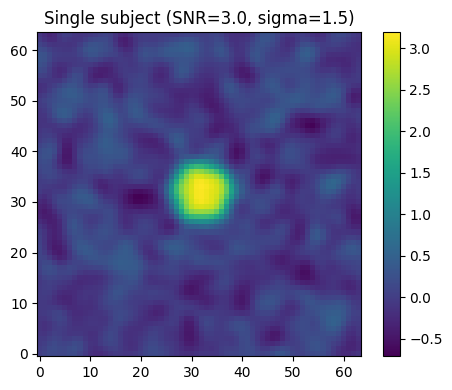

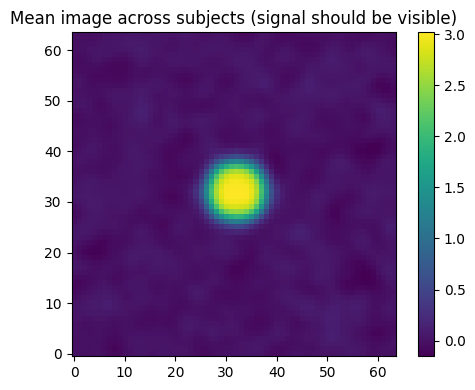

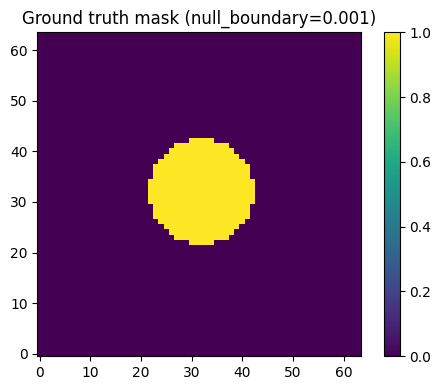

df = 19
cluster-forming t-threshold = 2.860934606449914
critical cluster size = 19
max cluster sizes (null) summary: min 2 median 10 max 213


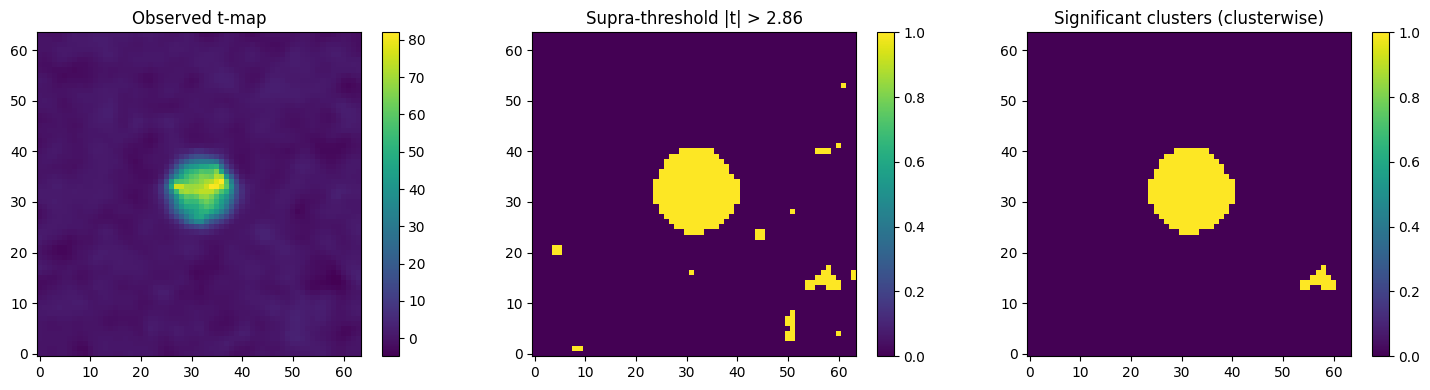

Sensitivity (TPR over truth mask) = 0.6539589442815249


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# --- Settings --
n_subj = 20
img_side_length = 64
smoothing_sigma = 1.5
alpha = 0.05
n_perm = 200
null_boundary = 1e-3

snr_demo = 3.0
signal_radius = 6
random_state = 0  # controls BOTH simulation + permutation RNG

# --- Simulate data (NEW VERSION) ---
data = hf.simulate_data(
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    snr=snr_demo,
    signal_radius=signal_radius,
    labels=False,            # one-sample
    random_state=random_state
)

# --- Quick visuals ---
plt.figure(figsize=(5,4))
plt.imshow(data[0], origin="lower")
plt.title(f"Single subject (SNR={snr_demo}, sigma={smoothing_sigma})")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.imshow(data.mean(axis=0), origin="lower")
plt.title("Mean image across subjects (signal should be visible)")
plt.colorbar()
plt.tight_layout()
plt.show()

# --- Ground truth mask (smoothed truth) ---
true_mask = hf.get_smoothed_truth_mask(
    img_side_length, img_side_length,
    sigma=smoothing_sigma,
    radius=signal_radius,
    null_boundary=null_boundary
)

plt.figure(figsize=(5,4))
plt.imshow(true_mask, origin="lower")
plt.title(f"Ground truth mask (null_boundary={null_boundary})")
plt.colorbar()
plt.tight_layout()
plt.show()

# --- Design / df ---
_, _, df = hf.build_design_matrix(n_subj, labels=False)

# cluster-forming threshold: p=0.01 two-sided
cluster_forming_thr = t.ppf(1 - 0.01/2, df)

# --- Clusterwise permutation test ---
tmap_obs, labeled_obs, sig_clusters_mask, crit_cluster_size, max_cluster_sizes, used_thr = (
    hf.clusterwise_permutation_test(
        data=data,
        labels=False,
        alpha=alpha,
        n_perm=n_perm,
        cluster_forming_thr=cluster_forming_thr,
        random_state=random_state
    )
)

print("df =", df)
print("cluster-forming t-threshold =", used_thr)
print("critical cluster size =", crit_cluster_size)
print(
    "max cluster sizes (null) summary:",
    "min", int(max_cluster_sizes.min()),
    "median", int(np.median(max_cluster_sizes)),
    "max", int(max_cluster_sizes.max())
)

# --- Show observed / supra-threshold / significant clusters ---
supra = (np.abs(tmap_obs) > used_thr)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(tmap_obs, origin="lower")
plt.title("Observed t-map")
plt.colorbar(fraction=0.046)

plt.subplot(1,3,2)
plt.imshow(supra, origin="lower")
plt.title(f"Supra-threshold |t| > {used_thr:.2f}")
plt.colorbar(fraction=0.046)

plt.subplot(1,3,3)
plt.imshow(sig_clusters_mask, origin="lower")
plt.title("Significant clusters (clusterwise)")
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()

# --- Sensitivity (TPR over truth mask) ---
tp = np.sum(sig_clusters_mask & true_mask)
total_true = np.sum(true_mask)
sensitivity = tp / total_true if total_true > 0 else 0.0
print("Sensitivity (TPR over truth mask) =", sensitivity)


In [10]:
import numpy as np
from scipy.stats import t

n_subj = 50
img_side_length = 64
alpha = 0.05
null_boundary = 1e-3

# "Fast test"
n_runs = 20
n_perm = 50
signal_radius = 6

test_snrs =   [0, 0.1, 0.175, 0.25, 0.4, 0.5, 0.6, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0]
test_sigmas = [0, 0.1, 0.25, 0.175, 0.4, 0.5, 0.6, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0]

# df for one-sample
_, _, df = hf.build_design_matrix(n_subj, labels=False)

# cluster-forming threshold: p=0.01 (two-sided)
cluster_forming_thr = t.ppf(1 - 0.01/2, df)
cluster_forming_thr


np.float64(2.67995197363155)

In [11]:
sens_mat, fwer_mat = hf.run_2d_sweep_clusterwise(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=alpha,
    labels=False,                 # ONE-SAMPLE ONLY
    signal_radius=signal_radius,
    n_perm=n_perm,
    null_boundary=null_boundary,
    cluster_forming_thr=cluster_forming_thr,
    random_state_base=0
)

sens_mat.shape, fwer_mat.shape


((21, 21), (21, 21))

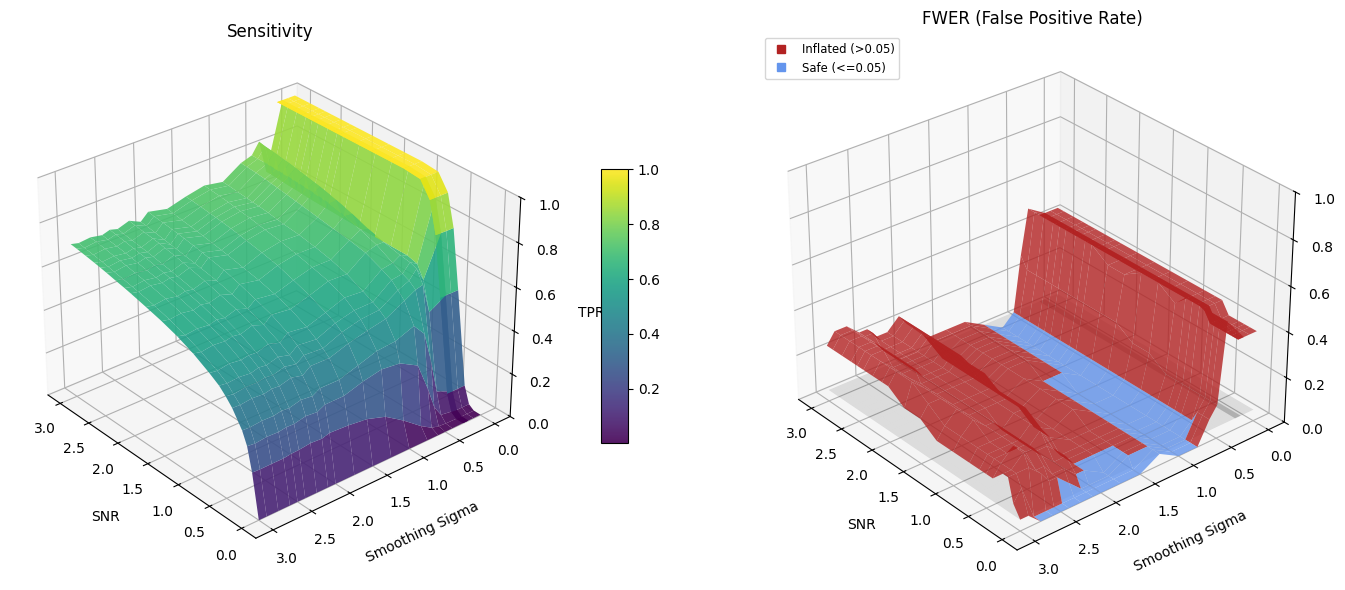

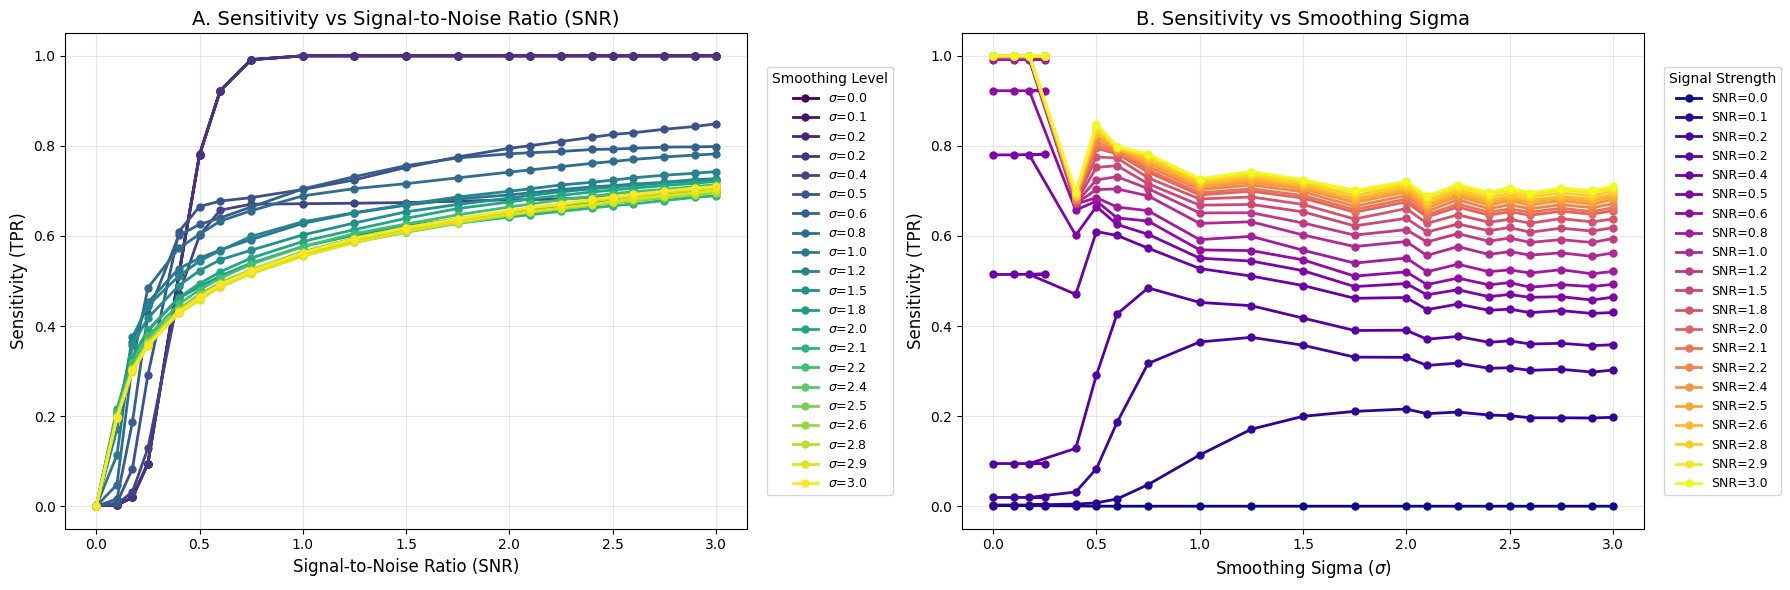

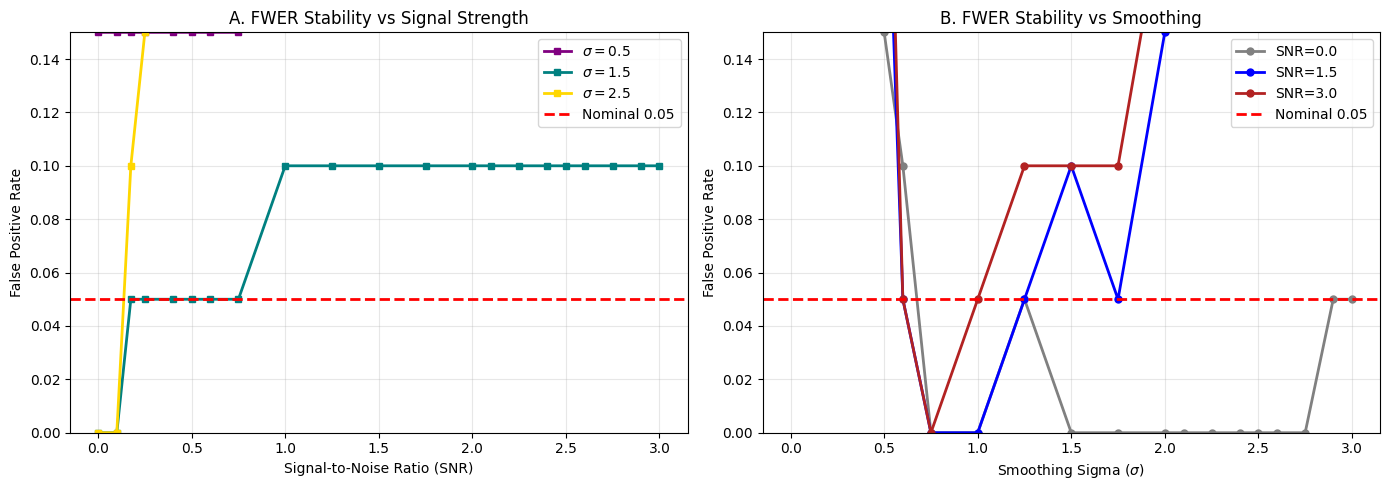

In [12]:
pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat, elev=30, azim=140)
pl.plot_sensitivity_analysis(test_snrs, test_sigmas, sens_mat)
pl.plot_fwer_stability(test_snrs, test_sigmas, fwer_mat, np.array(test_sigmas), np.array(test_snrs))


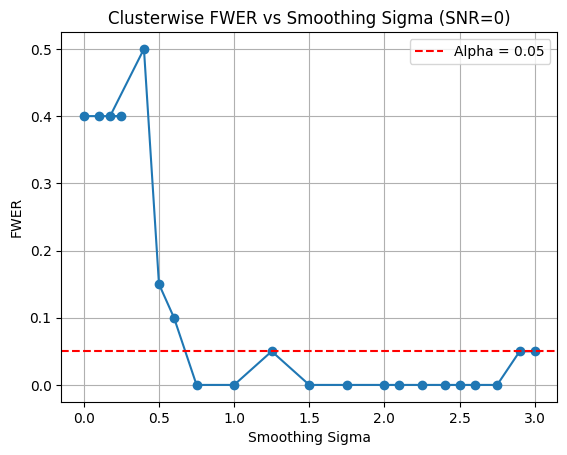

In [13]:
# Extract the SNR=0 column
snr0_idx = np.where(np.isclose(np.array(test_snrs), 0.0))[0][0]
fwer_snr0 = fwer_mat[:, snr0_idx]

plt.figure()
plt.plot(test_sigmas, fwer_snr0, marker='o')
plt.xlabel("Smoothing Sigma")
plt.ylabel("FWER")
plt.title("Clusterwise FWER vs Smoothing Sigma (SNR=0)")
plt.grid(True)
plt.axhline(y=0.05, linestyle='--', color='r', label='Alpha = 0.05')
plt.legend()
plt.show()


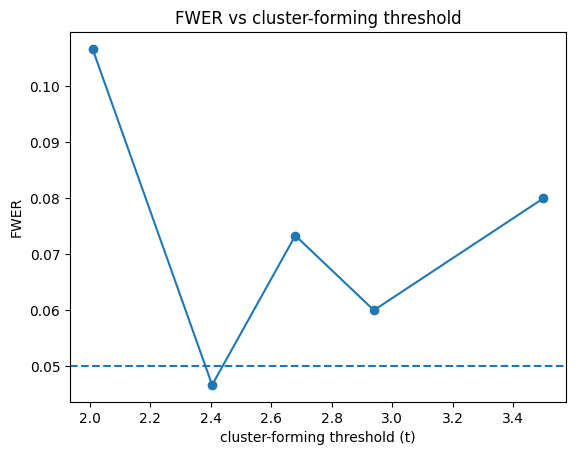

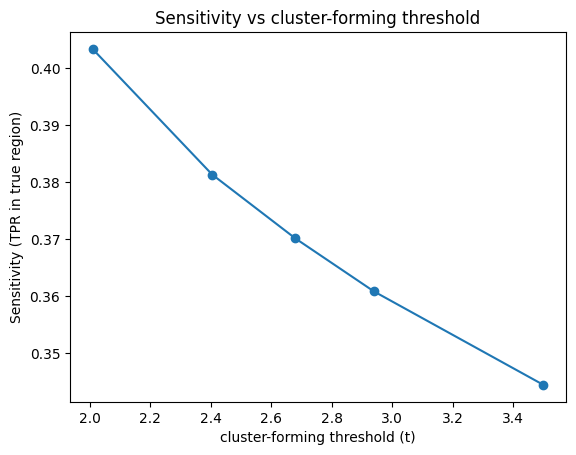

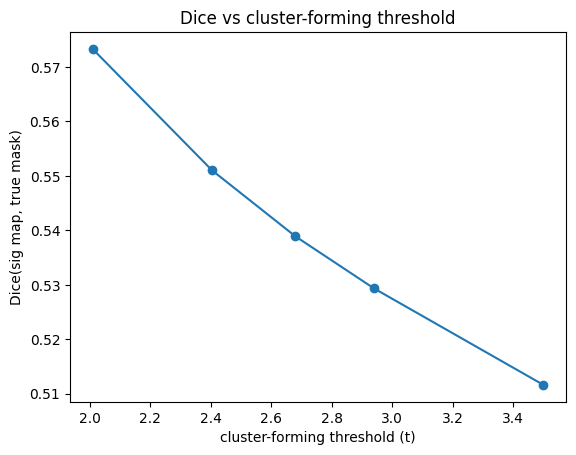

thr=2.010 | FWER=0.107 | Sens=0.403 | Dice=0.573
thr=2.405 | FWER=0.047 | Sens=0.381 | Dice=0.551
thr=2.680 | FWER=0.073 | Sens=0.370 | Dice=0.539
thr=2.940 | FWER=0.060 | Sens=0.361 | Dice=0.529
thr=3.500 | FWER=0.080 | Sens=0.344 | Dice=0.512


In [3]:
from scipy.stats import t as tdist
import matplotlib.pyplot as plt

n_subj = 50
labels = False
X, L, df = hf.build_design_matrix(n_subj, labels)

# Two-sided voxelwise thresholds:
p_list = [0.05, 0.02, 0.01, 0.005, 0.001]
thresholds = [tdist.ppf(1 - p/2, df) for p in p_list]

res = hf.run_threshold_sweep_clusterwise(
    n_runs=150,
    n_subj=n_subj,
    img_side=64,
    sigma=2.0,
    snr=1.0,
    alpha=0.05,
    thresholds=thresholds,
    labels=labels,
    signal_radius=6,
    n_perm=1000,
    random_state_base=123
)

plt.figure()
plt.plot(res["thr"], res["fwer"], marker="o")
plt.axhline(0.05, linestyle="--")
plt.xlabel("cluster-forming threshold (t)")
plt.ylabel("FWER")
plt.title("FWER vs cluster-forming threshold")
plt.show()

plt.figure()
plt.plot(res["thr"], res["sens"], marker="o")
plt.xlabel("cluster-forming threshold (t)")
plt.ylabel("Sensitivity (TPR in true region)")
plt.title("Sensitivity vs cluster-forming threshold")
plt.show()

plt.figure()
plt.plot(res["thr"], res["dice"], marker="o")
plt.xlabel("cluster-forming threshold (t)")
plt.ylabel("Dice(sig map, true mask)")
plt.title("Dice vs cluster-forming threshold")
plt.show()

# quick view
for thr, f, s, d in zip(res["thr"], res["fwer"], res["sens"], res["dice"]):
    print(f"thr={thr:.3f} | FWER={f:.3f} | Sens={s:.3f} | Dice={d:.3f}")


## Simulate data

In [14]:
n_subj = 20
Y, _ = simd.simulate_2d_data_snr(
    n_subjects=20,
    shape=(64, 64),
    sigma=2.0,
    mode="one-sample-signal",
    signal_radius=6,
    snr=1.0,
    random_state=0
)


plt.imshow(Y.mean(axis=0))
plt.title("Mean Image Across Subjects (one-sample)")
plt.colorbar()
plt.show()


NameError: name 'simd' is not defined

Above we can clearly see the reigon we have put the fake signal and we can see the random noise around it.

# Fit GLM

We fit the general linear model:

    Y = Xβ + ε

We then show one beta map.


In [ ]:
design, L = hf.make_design_and_contrast(Y.shape[0], test_type="one-sample")

betas, resid = hf.fit_glm(design, Y)

plt.imshow(betas[0])
plt.title("Beta Map (Intercept / Mean)")
plt.colorbar()
plt.show()

# Compute T-Map

We create the t-map


In [ ]:
tmap = hf.tmap_from_L(design, betas, resid, L)

plt.imshow(tmap, cmap="RdBu_r")
plt.title("Observed t-Map (two-sided)")
plt.colorbar()
plt.show()

# Compute t-Threshold

We compute the t-threshold for p=0.05.


In [ ]:
df = design.shape[0] - design.shape[1]
t_threshold = t.ppf(1 - 0.05/2, df)
print("df =", df)
print("Two-sided cluster-defining t-threshold =", t_threshold)


# Cluster Formation

We apply the threshold and display:
- binary threshold mask
- labeled clusters


In [ ]:
cluster_sizes, mask, labeled, n_clusters = hf.get_clusters_and_mask(tmap, t_threshold)
print("Number of clusters:", n_clusters)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(mask, cmap="gray")
plt.title("Mask of voxels above |CDT|")

plt.subplot(1,2,2)
plt.imshow(labeled, cmap="tab20")
plt.title("Labeled Clusters (two-sided)")

plt.show()


# Permutation Cluster Test

We run the full permutation test and display:
- t-map
- cluster labels
- significant clusters


In [ ]:
tmap_obs, labeled_obs, sig_clusters_mask, crit_cluster_size, max_cluster_sizes = hf.permutation_cluster_test(
    Y, design, L,
    threshold=t_threshold,
    n_permutations=300,
    alpha=0.05,
    random_state=0,
    test_type="one-sample"
)


# Visualization


In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Observed t-map")
plt.imshow(tmap_obs, cmap='RdBu_r')
plt.colorbar()

plt.subplot(1,3,2)
plt.title("Cluster labels")
plt.imshow(labeled_obs, cmap='tab20')
plt.colorbar()

plt.subplot(1,3,3)
plt.title("Significant Clusters (clusterwise corrected)")
plt.imshow(sig_clusters_mask, cmap="Reds")
plt.colorbar()

plt.show()

print("Critical cluster size =", crit_cluster_size)

plt.hist(max_cluster_sizes, bins=30)
plt.axvline(crit_cluster_size, color='red', linestyle='--')
plt.title("Null distribution of max cluster sizes (two-sided)")
plt.xlabel("Max cluster size")
plt.ylabel("Frequency")
plt.show()

# Null Distribution of Max Cluster Sizes


In [ ]:
plt.hist(max_cluster_sizes, bins=30)
plt.axvline(crit_cluster_size, color='red', linestyle='--')
plt.title("Null distribution of max cluster sizes")
plt.xlabel("Cluster size")
plt.ylabel("Frequency")
plt.show()


# Method explained

Frist we fit a voxel-wise GLM
Y=Xβ+ε
where
Y = voxel intensities across subjects
X = design matrix (intercept + group indicator)
L = contrast vector testing the group effect
β = estimated parameters

Then we compute a t-statistic map for the contrast
Lβ.
and threshold the t-map at a chosen t-value. In this case i used  alpha = 0.05.

After this we begin to identify spatial clusters of supra-threshold voxels.

Then we use permutation testing to generate a null distribution of cluster sizes by:
- Shuffling group labels using a permutation matrix
- Recomputing the t-map
- Extracting the largest cluster size for each permutation
- Determining a critical cluster size
- comparing real clusters to the null distribution. If an observed cluster size ≥ critical size then the cluster is marked as significant.

# Assumptions
The main assumtion for this method is the exchagability under the null hypothesis which is that the subjects labels can be permutaed without any underlying change to the distribution of the risiduals if the null is true.

## Evaluating the method

In [ ]:
from scipy.stats import t
import importlib
importlib.reload(hf)

test_snrs = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0]
test_sigmas = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0] # Low smooth -> High smooth
img_side_length = 64
df = n_subj - 1
t_threshold = t.ppf(1 - 0.05/2, df)

sens_mat, fwer_mat = hf.run_2d_sweep_clusterwise(
    n_runs=20,
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=0.05,
    threshold=t_threshold,
    n_perm=50,
    signal_radius=6,
    buffer_width=4
)

hf.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat)
hf.plot_net_performance_3d(test_snrs, test_sigmas, sens_mat, fwer_mat)
